# Word2Vec

## 학습 목표

- 원-핫 인코딩의 한계와 분산 표현의 필요성을 설명할 수 있습니다.
- Word2Vec이 주변 문맥을 이용해 단어 벡터를 학습한다는 점을 이해합니다.
- CBOW와 Skip-gram의 차이를 구분합니다.
- `gensim.models.Word2Vec`의 주요 하이퍼파라미터를 조정할 수 있습니다.
- 학습된 벡터로 유사 단어 검색, 저장/로드, 간단한 시각화를 수행합니다.


## 1. 왜 Word2Vec인가?

전통적인 원-핫 인코딩은 단어를 고유 ID처럼 표현합니다. 예를 들어 `배송`, `택배`, `반품`은 서로 완전히 다른 축에 놓입니다.

문제는 의미적 유사도가 표현되지 않는다는 점입니다.

- `배송`과 `택배`는 실제로 가까운 단어입니다.
- 원-핫 벡터에서는 두 단어의 내적이 0입니다.
- 단어 수가 많아질수록 벡터 차원이 커지고 희소해집니다.

Word2Vec은 단어를 조밀한 실수 벡터로 표현합니다. 비슷한 문맥에서 등장하는 단어는 비슷한 벡터를 갖도록 학습됩니다.


## 2. Word2Vec의 핵심 가정

Word2Vec은 분포 가설에 기반합니다.

> 비슷한 문맥에서 등장하는 단어는 비슷한 의미를 가진다.

예를 들어 다음 문장들을 보면 `빠르다`, `신속하다`, `만족하다`는 긍정적 배송 경험 주변에서 자주 등장합니다.

- 고객 배송 빠르다 만족하다
- 사용자 택배 신속하다 만족하다
- 리뷰 배송 빠르다 칭찬하다

학습이 충분히 되면 이런 단어들은 벡터 공간에서 가까운 위치에 놓입니다.


In [ ]:
# pip install --upgrade gensim
# uv add gensim

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


## 3. 예제 코퍼스 준비

`gensim`의 Word2Vec 입력은 문장 리스트입니다. 각 문장은 이미 토큰화된 단어 리스트여야 합니다.

형태는 다음과 같습니다.

```python
[
    ['고객', '배송', '빠르다', '만족하다'],
    ['사용자', '택배', '신속하다', '만족하다'],
]
```

실무에서는 형태소 분석기 또는 토크나이저로 문장을 먼저 토큰화합니다. 여기서는 단순하게 유지하기 위해 이미 띄어쓰기 단위로 정리된 작은 코퍼스를 사용합니다.


In [3]:
base_sentences = [
    '고객 배송 빠르다 만족하다',
    '사용자 배송 빠르다 칭찬하다',
    '리뷰 배송 신속하다 만족하다',
    '고객 택배 신속하다 만족하다',
    '사용자 택배 빠르다 칭찬하다',
    '고객 배송 느리다 불만이다',
    '사용자 택배 지연되다 불만이다',
    '리뷰 배송 느리다 불평하다',
    '고객 환불 지연되다 불만이다',
    '사용자 교환 지연되다 불평하다',
    '상품 품질 좋다 만족하다',
    '제품 품질 뛰어나다 칭찬하다',
    '상품 성능 좋다 만족하다',
    '제품 성능 뛰어나다 추천하다',
    '가격 저렴하다 만족하다',
    '가격 합리적이다 추천하다',
    '결제 오류 발생하다 불만이다',
    '로그인 오류 발생하다 불편하다',
    '앱 오류 잦다 불편하다',
    '고객센터 친절하다 만족하다',
    '상담원 친절하다 칭찬하다',
    '고객센터 응답 빠르다 만족하다',
]


In [4]:
# 토큰화(빈칸을 기준으로)
tokenized_sentences = [sentence.split() for sentence in base_sentences]

# 예제 매장이 너무 적으면 단어쌍이 충분히 반복되지 않아 임베딩이 불안정할 수 있음
# 같은 문장을 40번 반복.
train_sentences = tokenized_sentences * 40

# 학습 순서에 따른 편향을 줄이기 위해서 문장 순서를 섞음
random.shuffle(train_sentences)

print('문장 수:', len(train_sentences))
print('예시 문장:', train_sentences[:3])

문장 수: 880
예시 문장: [['리뷰', '배송', '느리다', '불평하다'], ['고객', '배송', '빠르다', '만족하다'], ['가격', '저렴하다', '만족하다']]


## 4. CBOW 방식으로 Word2Vec 학습

CBOW는 주변 단어들로 중심 단어를 예측합니다.

예를 들어 `고객 배송 빠르다 만족하다`에서 중심 단어가 `빠르다`라면 주변 단어 `고객`, `배송`, `만족하다`를 보고 `빠르다`를 맞히는 방향으로 학습합니다.

`gensim`에서는 `sg=0`이면 CBOW입니다.


In [5]:
cbow_model = Word2Vec(
    sentences=train_sentences,             # 토큰화된 문장 등의 리스트
    vector_size=50,                        # 50차원 숫자 벡터로 표현(차원 너무 작으면 표현력이 부족, 반대면 과적합)
    window=2,                              # 주변 단어를 고려하는 범위(중심 단어 기준)
    min_count=1,                           # 최소 등장 횟수.
    workers=1,
    sg=0,                                  # sg=1 : Skip-gram, sg=0 : CBOW
    seed=SEED,
    epochs=100,
)

print('어휘 수:', len(cbow_model.wv))
print('임베딩 행렬 크기:', cbow_model.wv.vectors.shape)


어휘 수: 36
임베딩 행렬 크기: (36, 50)


## 5. 주요 하이퍼파라미터

- `vector_size`: 단어 벡터 차원입니다. 값이 클수록 표현력은 커지지만 데이터와 시간이 더 필요합니다.
- `window`: 중심 단어 기준 좌우 문맥 범위입니다.
- `min_count`: 이 빈도보다 적게 등장한 단어는 어휘에서 제외합니다.
- `workers`: 병렬 학습에 사용할 CPU 작업자 수입니다. 재현성이 중요하면 `workers=1`을 사용합니다.
- `sg`: `0`은 CBOW, `1`은 Skip-gram입니다.
- `epochs`: 전체 코퍼스를 반복 학습하는 횟수입니다.


In [ ]:
# 어떤 단어 벡터가 학습되었는지 확인
vocab = cbow_model.wv.index_to_key
pd.DataFrame({
    'token': vocab,
    'count': [cbow_model.wv.get_vecattr(token, 'count') for token in vocab],
}).head(10)


,token,count
0,만족하다,320
1,배송,200
2,불만이다,160
3,칭찬하다,160
4,사용자,160
5,빠르다,160
6,고객,160
7,택배,120
8,오류,120
9,지연되다,120


## 6. 단어 벡터 확인

학습된 모델의 `wv`는 단어 벡터를 다루는 객체입니다.

- `model.wv['배송']`: 특정 단어의 벡터
- `model.wv.most_similar('배송')`: 가장 가까운 단어 검색
- `model.wv.similarity('배송', '택배')`: 두 단어의 코사인 유사도


In [7]:
word = '배송'
vector = cbow_model.wv[word]

print(word, '벡터 차원:', vector.shape)
print(vector[:10])


배송 벡터 차원: (50,)
[ 0.29144058 -0.35060537 -0.18489751  0.07447591  0.41220954 -0.18590148
 -0.3270932   0.42981717  0.1386879   0.15445112]


In [9]:
# 기준 단어와 가장 비슷한 단어들을 확인하는 함수
def show_similar(model, word, topn=5):
    print(f'[{word}]와 가까운 단어')
    # 점수는 보통 -1~1 범위이며, 1에 가까울 수록 벡터 방향이 비슷.
    for token, score in model.wv.most_similar(word, topn=topn):
        print(f'{token:>8s}  {score:.3f}')

show_similar(cbow_model, '배송')
print()
show_similar(cbow_model, '만족하다')
print()
show_similar(cbow_model, '오류')


[배송]와 가까운 단어
    신속하다  0.791
    불평하다  0.786
      리뷰  0.773
      고객  0.772
     느리다  0.741

[만족하다]와 가까운 단어
      상품  0.656
      응답  0.614
      좋다  0.567
    고객센터  0.567
    신속하다  0.552

[오류]와 가까운 단어
     로그인  0.923
    불편하다  0.910
    발생하다  0.885
      잦다  0.865
      결제  0.863


In [10]:
# 특정 단어쌍의 코사인 유사도를 비교
pairs = [
    ('배송', '택배'),
    ('빠르다', '신속하다'),
    ('만족하다', '칭찬하다'),
    ('불만이다', '불편하다'),
    ('배송', '오류'),
]

pd.DataFrame(
    [(a, b, cbow_model.wv.similarity(a, b)) for a, b in pairs],
    columns=['단어1', '단어2', 'cosine_similarity'],
).sort_values('cosine_similarity', ascending=False)


,단어1,단어2,cosine_similarity
0,배송,택배,0.732565
1,빠르다,신속하다,0.708005
3,불만이다,불편하다,0.560179
2,만족하다,칭찬하다,0.468576
4,배송,오류,0.234952


## 7. Skip-gram 방식과 비교

Skip-gram은 중심 단어로 주변 단어를 예측합니다.

- CBOW: 주변 단어 -> 중심 단어
- Skip-gram: 중심 단어 -> 주변 단어

일반적으로 Skip-gram은 희소 단어 표현에 강하고, CBOW는 학습이 빠른 편입니다. 데이터와 목적에 따라 선택합니다.

`gensim`에서는 `sg=1`이면 Skip-gram입니다.


In [11]:
skipgram_model = Word2Vec(
    sentences=train_sentences,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1,
    seed=SEED,
    epochs=100,
)

comparison = []
for target in ['배송', '만족하다', '오류']:
    cbow_top = ', '.join([w for w, _ in cbow_model.wv.most_similar(target, topn=3)])
    sg_top = ', '.join([w for w, _ in skipgram_model.wv.most_similar(target, topn=3)])
    comparison.append((target, cbow_top, sg_top))

pd.DataFrame(comparison, columns=['기준 단어', 'CBOW top3', 'Skip-gram top3'])


,기준 단어,CBOW top3,Skip-gram top3
0,배송,"신속하다, 불평하다, 리뷰","리뷰, 불평하다, 신속하다"
1,만족하다,"상품, 응답, 좋다","상품, 응답, 고객센터"
2,오류,"로그인, 불편하다, 발생하다","불편하다, 로그인, 잦다"


## 8. 모델 저장과 로드

학습된 벡터는 재사용할 수 있도록 저장합니다. `word2vec_format`은 다른 도구와 호환성이 좋아 실습 자료에서 자주 사용합니다.


In [ ]:
save_path = 'word2vec_kor_sample.vec'

# 저장
cbow_model.wv.save_word2vec_format(save_path)
loaded_vectors = KeyedVectors.load_word2vec_format(save_path)

# 로드 -> 불러온 객체는 추가 학습보다는 유사도 조회, 벡터 추출에 주로 사용
print('로드된 어휘 수:', len(loaded_vectors))
print(loaded_vectors.most_similar('배송', topn=5))


로드된 어휘 수: 36
[('신속하다', 0.790987491607666), ('불평하다', 0.7864975929260254), ('리뷰', 0.7729572057723999), ('고객', 0.7724866271018982), ('느리다', 0.7414661645889282)]


## 9. 임베딩 공간 시각화

Word2Vec 벡터는 보통 50차원, 100차원, 300차원처럼 고차원입니다. 사람이 보기 위해 PCA, t-SNE, UMAP 등으로 2차원에 투영합니다.


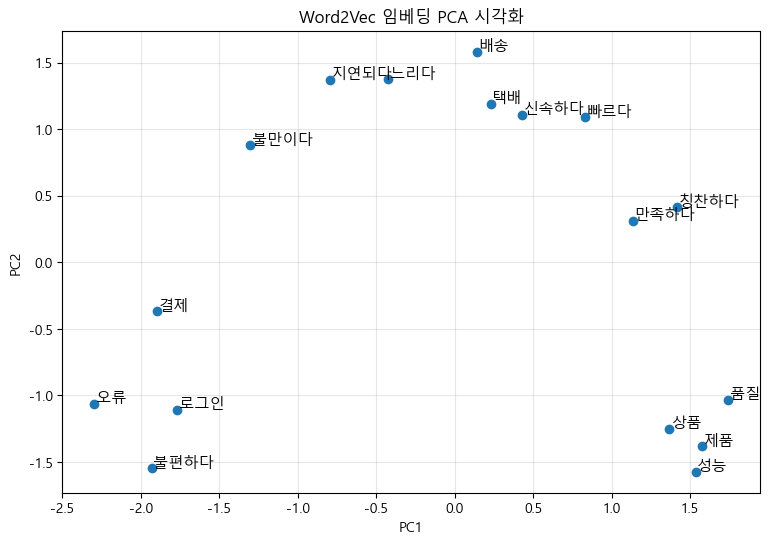

In [13]:
selected_words = [
    '배송', '택배', '빠르다', '신속하다', '느리다', '지연되다',
    '만족하다', '칭찬하다', '불만이다', '불편하다',
    '상품', '제품', '품질', '성능', '오류', '결제', '로그인',
]

vectors = np.array([cbow_model.wv[word] for word in selected_words])

# PCA를 사용해 50차원 벡터를 2차원 좌표로 압축한 뒤 산점도로 시각화
points = PCA(n_components=2, random_state=SEED).fit_transform(vectors)

plt.figure(figsize=(9, 6))
plt.scatter(points[:, 0], points[:, 1])

for word, (x, y) in zip(selected_words, points):
    plt.text(x + 0.01, y + 0.01, word, fontsize=11)

plt.title('Word2Vec 임베딩 PCA 시각화')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()


## 10. Word2Vec의 한계: OOV

Word2Vec은 학습 어휘에 없는 단어를 처리하지 못합니다. 이를 OOV, Out Of Vocabulary 문제라고 합니다.

예를 들어 `배송지연`이라는 단어가 학습 코퍼스에 없으면, `배송`과 `지연되다`를 알고 있어도 `배송지연` 벡터를 바로 만들 수 없습니다.

FastText는 단어를 문자 n-gram 단위로 쪼개 학습하기 때문에 이런 OOV 문제를 어느 정도 완화합니다.


In [14]:
for word in ['배송', '배송지연']:
    if word in cbow_model.wv:
        print(f'{word}: 벡터 있음')
    else:
        print(f'{word}: OOV - 학습 어휘에 없음')


배송: 벡터 있음
배송지연: OOV - 학습 어휘에 없음


## 강의 정리

- Word2Vec은 단어를 의미 공간의 조밀한 벡터로 바꿉니다.
- 핵심 가정은 비슷한 문맥에서 등장하는 단어는 비슷한 의미를 가진다는 것입니다.
- CBOW는 주변 단어로 중심 단어를 예측하고, Skip-gram은 중심 단어로 주변 단어를 예측합니다.
- `vector_size`, `window`, `min_count`, `sg`, `epochs`가 주요 하이퍼파라미터입니다.
- 학습된 벡터는 유사도 검색, 초기 임베딩, 문서 표현, 추천/검색 feature 등으로 활용할 수 있습니다.
- Word2Vec은 OOV에 약하며, 이 한계를 보완하는 대표 모델이 FastText입니다.
